# Netflix Dataset

### import and load data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# read csv file
df = pd.read_csv("C:\\Users\\Administrator\\Downloads\\archive(3)\\netflix_titles.csv")

In [2]:
print(df.head())
print(df.info())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

## Data Cleaning

In [4]:
# Remove extra spaces
df['date_added'] = df['date_added'].str.strip()

# Convert to datetime safely
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Fill missing dates (optional)
df['date_added'].fillna(method='ffill', inplace=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_15440\4066311421.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['date_added'].fillna(method='ffill', inplace=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_15440\4066311421.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date_added'].fillna(method='ffill', inplace=True)


In [5]:
# Fill missing values
df['director'].fillna("Unknown", inplace=True)
df['cast'].fillna("Unknown", inplace=True)
df['country'].fillna("Unknown", inplace=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_15440\3758377682.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna("Unknown", inplace=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_15440\3758377682.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

## Feature engineering

In [6]:
# Extract year
df['year_added'] = df['date_added'].dt.year

# Movie or TV show
df['is_movie'] = df['type'].apply(lambda x: 1 if x == "Movie" else 0)

# Release decade
df['decade'] = (df['release_year']//10)*10

## Visualization

#### Pie chart (Movies vs TV shows)

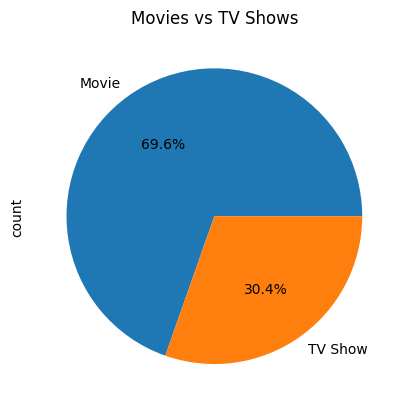

In [7]:
df['type'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Movies vs TV Shows")
plt.show()

#### Line plot (Content per year)

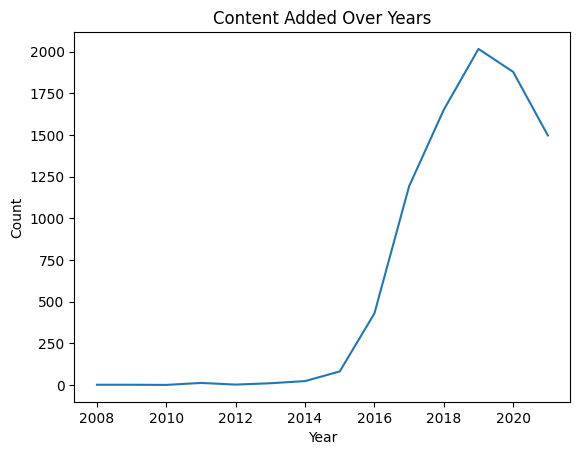

In [8]:
df['year_added'].value_counts().sort_index().plot()
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

#### Bar Plot (Top Genres)

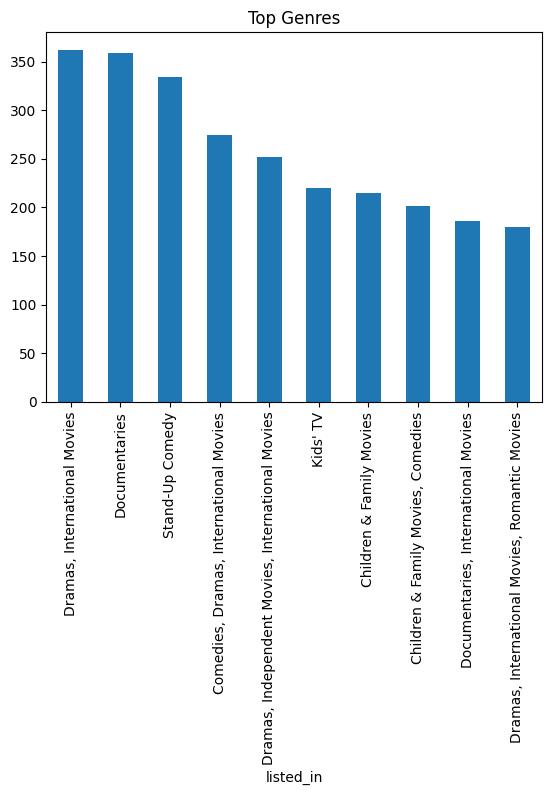

In [9]:
df['listed_in'].value_counts().head(10).plot.bar()
plt.title("Top Genres")
plt.show()

#### Top Countries

In [10]:
print(df['country'].value_counts().head(5))

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
Name: count, dtype: int64
